In [36]:
import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt
import astropy.units as u
%matplotlib widget
from threeML import XYLike, DataList, Model, PointSource, SpectralComponent, BayesianAnalysis,\
      plot_spectra, Uniform_prior, ZDust, TbAbs, IndependentVariable, clone_model, load_analysis_results
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from bhjet.threeML_plugins.BHJetPlugin import BHJetPlugin
from bhjet.threeML_plugins.TargetBlackBody import TargetBlackBody
from bhjet.threeML_plugins.BandLimitedAbsorption import BandLimitedAbsorption

In [12]:
bhjet3ml = BHJetPlugin()
bhjet3ml._setup(
    Emin_eV=1e-6, Emax_eV=1e15, 
    dlgz=0.3, verbosity_level=0, 
    compton_threshold=1e-10,
    include_counterjet=True, cache_rtol=1e-4)

bbt1 = TargetBlackBody()

bhjet3ml.add_target(bbt1, "bb1")

component1 = SpectralComponent("BHJet", shape=bhjet3ml)
component2 = SpectralComponent("BB1", shape=bbt1)

ps = PointSource("fake_source", ra=0, dec=0, components=[component1, component2])
model = Model(ps)

In [13]:
model.link(bbt1.lg_distance, bhjet3ml.lg_distance)
model.link(bbt1.redshift, bhjet3ml.redshift)
model

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (27):
--------------------

                                           value min_value max_value unit
fake_source...lg_mass_bh                     9.0       1.0      15.0     
fake_source...lg_jet_power_eddington        -5.0     -10.0       5.0     
fake_source...lg_z_jet_launching             0.3       0.0       5.0     
fake_source...lg_r_initial                   0.7       0.0       5.0     
fake_source...lg_z_end_of_acceleration       5.3       0.0      10.0     
fake_source...lg_z_dissipation               2.0       0.0      10.0     
fake_source...lg_z_max_calculation           5.5       0.0      10.0     
fake_source...lg_sigma_final                 0.0      -5.0       5.0     
fake_source...lg_gamma_final                 1.0   0.00001       5.0     
fake_source...plasma_beta_jet_base           0.0       0.0  100000.0     
...                                          0.0     -10.0      10.0     
fake_source...lg_opening_angle_constant    -0.82      -5.0       5.0     
fake_source...lg_factor_break_electrons      0.0     -10.0      10.0     
fake_source...lg_factor_break_protons        0.0     -10.0      10.0     
fake_source...index_injected_electrons       2.0     -10.0      10.0     
fake_source...index_injected_protons         2.0     -10.0      10.0     
fake_source...theta_obs                     17.0       0.0     180.0     
fake_source...lg_distance                    4.0       0.0      10.0     
fake_source...redshift                   0.00428       0.0    1000.0     
fake_source...lg_temperature                -3.5     -10.0      10.0     
fake_source...lg_energy_density             -9.0     -20.0      10.0     
fake_source...lg_luminosity                 44.0       0.0      60.0     

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (2):
----------------------

              fake_source.spectrum.BB1.TargetBlackBody.lg_distance
linked to      fake_source.spectrum.BHJet.BHJetPlugin.lg_dist...  
function                                                    Line  
current value                                                4.0  
unit                                                              

              fake_source.spectrum.BB1.TargetBlackBody.redshift
linked to       fake_source.spectrum.BHJet.BHJetPlugin.redshift
function                                                   Line
current value                                           0.00428
unit                                                           


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [14]:
clone_model(model)

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (27):
--------------------

                                           value min_value max_value unit
fake_source...lg_mass_bh                     9.0       1.0      15.0     
fake_source...lg_jet_power_eddington        -5.0     -10.0       5.0     
fake_source...lg_z_jet_launching             0.3       0.0       5.0     
fake_source...lg_r_initial                   0.7       0.0       5.0     
fake_source...lg_z_end_of_acceleration       5.3       0.0      10.0     
fake_source...lg_z_dissipation               2.0       0.0      10.0     
fake_source...lg_z_max_calculation           5.5       0.0      10.0     
fake_source...lg_sigma_final                 0.0      -5.0       5.0     
fake_source...lg_gamma_final                 1.0   0.00001       5.0     
fake_source...plasma_beta_jet_base           0.0       0.0  100000.0     
...                                          0.0     -10.0      10.0     
fake_source...lg_opening_angle_constant    -0.82      -5.0       5.0     
fake_source...lg_factor_break_electrons      0.0     -10.0      10.0     
fake_source...lg_factor_break_protons        0.0     -10.0      10.0     
fake_source...index_injected_electrons       2.0     -10.0      10.0     
fake_source...index_injected_protons         2.0     -10.0      10.0     
fake_source...theta_obs                     17.0       0.0     180.0     
fake_source...lg_distance                    4.0       0.0      10.0     
fake_source...redshift                   0.00428       0.0    1000.0     
fake_source...lg_temperature                -3.5     -10.0      10.0     
fake_source...lg_energy_density             -9.0     -20.0      10.0     
fake_source...lg_luminosity                 44.0       0.0      60.0     

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (2):
----------------------

              fake_source.spectrum.BB1.TargetBlackBody.lg_distance
linked to      fake_source.spectrum.BHJet.BHJetPlugin.lg_dist...  
function                                                    Line  
current value                                                4.0  
unit                                                              

              fake_source.spectrum.BB1.TargetBlackBody.redshift
linked to       fake_source.spectrum.BHJet.BHJetPlugin.redshift
function                                                   Line
current value                                           0.00428
unit                                                           


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

Text(0, 0.5, 'E²dN/dEdtdA [keV/cm²s]')

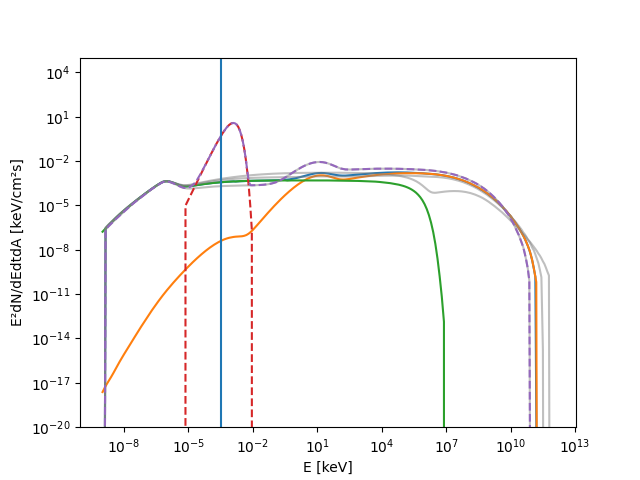

In [15]:
%matplotlib widget
EskeV = np.logspace(-9, 12, 300)
fig, ax = plt.subplots()

bbt1.lg_energy_density = -1
bhjet3ml.lg_jet_power_eddington.value = -5


ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV))
ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, 1e30
))
ax.loglog(bhjet3ml.Egrid_keV, bhjet3ml.Egrid_keV* bhjet3ml.bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, 1e30
))

for i in np.arange(-4, 2, 2):
    bbt1.lg_energy_density = i
    ax.loglog(EskeV, EskeV**2*bhjet3ml(EskeV), c="grey", alpha=0.5)

ax.loglog(EskeV, EskeV**2*bbt1(EskeV), ls="--")
ax.loglog(EskeV, EskeV**2*model.fake_source(EskeV), ls="--")
ax.axvline(10**bbt1.lg_temperature.value)
ax.set_ylim(1e-20, 1e5)
ax.set_xlabel("E [keV]")
ax.set_ylabel("E²dN/dEdtdA [keV/cm²s]")

In [16]:
%%time
bhjet3ml.lg_jet_power_eddington.value *= 0.9
bhjet3ml(EskeV)


CPU times: user 366 ms, sys: 2.16 ms, total: 368 ms
Wall time: 375 ms


array([1.00000000e-100, 2.22113014e-022, 3.47322870e+011, 3.32613028e+011,
       3.11772133e+011, 2.89926678e+011, 2.70700933e+011, 2.56811659e+011,
       2.39364623e+011, 2.20208384e+011, 2.00106018e+011, 1.83727380e+011,
       1.69799173e+011, 1.59053705e+011, 1.55162650e+011, 1.33259367e+011,
       1.13474286e+011, 1.02727017e+011, 9.21405104e+010, 8.26085576e+010,
       7.40714258e+010, 6.61144028e+010, 5.81900096e+010, 5.10320785e+010,
       4.54311259e+010, 3.98616896e+010, 3.47959046e+010, 3.03023133e+010,
       2.66090188e+010, 2.32471269e+010, 2.01873509e+010, 1.73720093e+010,
       1.51442086e+010, 1.31979486e+010, 1.12818651e+010, 9.68238352e+009,
       8.30073932e+009, 7.09641897e+009, 5.99673836e+009, 5.12032398e+009,
       4.39989554e+009, 3.73039031e+009, 3.12286638e+009, 2.59466794e+009,
       2.14326358e+009, 1.67775998e+009, 1.27275883e+009, 9.36855736e+008,
       6.47777631e+008, 4.38285633e+008, 2.90585982e+008, 1.87670335e+008,
       1.20283793e+008, 7

In [17]:
%%time
bhjet3ml.lg_jet_power_eddington.value *= 0.9
# bbt1.lg_distance.value *= 0.9
for i in range(100):
    bhjet3ml(EskeV)


CPU times: user 375 ms, sys: 4.3 ms, total: 379 ms
Wall time: 387 ms


In [18]:

bhjet3ml.lg_jet_power_eddington.min_value = -6
bhjet3ml.lg_jet_power_eddington.max_value = -4
for par in bhjet3ml.parameters:
    bhjet3ml.parameters[par].free = False
    bhjet3ml.parameters[par].delta = 0.1
    bhjet3ml.parameters[par].prior = Uniform_prior(
        lower_bound=bhjet3ml.parameters[par].min_value,
        upper_bound=bhjet3ml.parameters[par].max_value)

bhjet3ml.lg_jet_power_eddington.free = True

bbt1.lg_temperature.min_value = -10
bbt1.lg_temperature.max_value = -3
bbt1.lg_temperature.value = -5
for par in bbt1.parameters:
    bbt1.parameters[par].free = False
    bbt1.parameters[par].delta = 0.1
    bbt1.parameters[par].prior = Uniform_prior(
        lower_bound=bbt1.parameters[par].min_value,
        upper_bound=bbt1.parameters[par].max_value)
bbt1.lg_temperature.free = True

# bbt2.lg_temperature.min_value = -4
# bbt2.lg_temperature.max_value = 0
# bbt2.lg_temperature.value = -3
# for par in bbt2.parameters:
#     bbt2.parameters[par].free = False
#     bbt2.parameters[par].delta = 0.1
#     bbt2.parameters[par].prior = Uniform_prior(
#         lower_bound=bbt2.parameters[par].min_value,
#         upper_bound=bbt2.parameters[par].max_value)
# bbt2.lg_temperature.free = True

22:05:19 INFO      Using Gaussian statistic (equivalent to chi^2) with the provided errors.            ]8;id=262000;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py\XYLike.py]8;;\:]8;id=713363;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/plugins/XYLike.py#93\93]8;;\

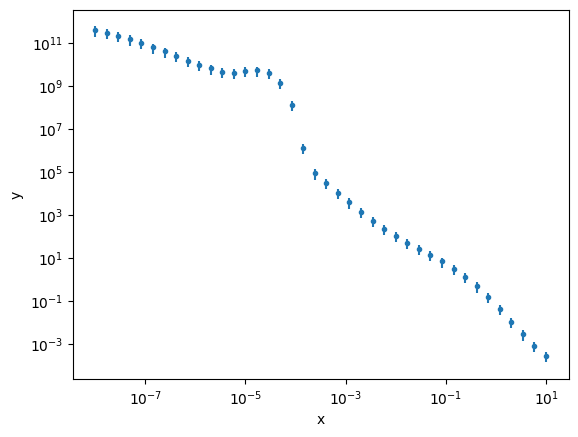

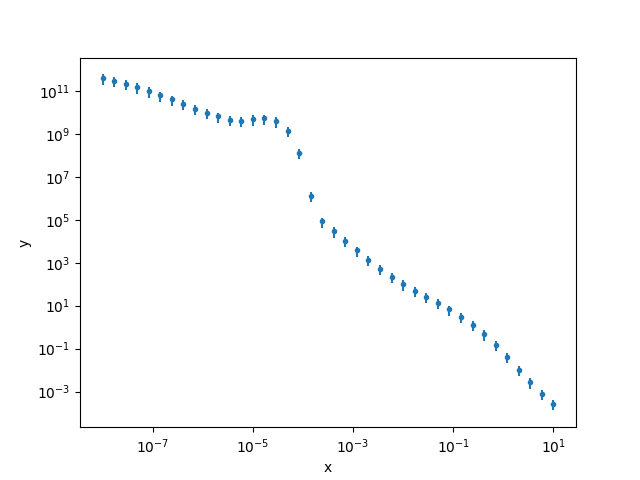

In [28]:
fake_ebins = np.logspace(-8, 1, 40)

data_points = model.fake_source(fake_ebins)
uncertainties = 0.5 * data_points 
fake_data = XYLike("fake_data", x=fake_ebins, y=data_points, yerr=uncertainties)

# fake_data = XYLike.from_function("fake_data", bbt1 + bhjet3ml, 
#                                  fake_ebins, 0.3* (bbt1(fake_ebins) + bhjet3ml(fake_ebins)))
fake_data.plot(x_scale='log', y_scale='log')

In [29]:
model

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                     value min_value max_value unit
fake_source...lg_jet_power_eddington -4.05      -6.0      -4.0     
fake_source...lg_temperature          -5.0     -10.0      -3.0     

Fixed parameters (31):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (2):
----------------------

              fake_source.spectrum.BB1.TargetBlackBody.lg_distance
linked to      fake_source.spectrum.BHJet.BHJetPlugin.lg_dist...  
function                                                    Line  
current value                                                4.0  
unit                                                              

              fake_source.spectrum.BB1.TargetBlackBody.redshift
linked to       fake_source.spectrum.BHJet.BHJetPlugin.redshift
function                                                   Line
current value                                           0.00428
unit                                                           


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [30]:
data = DataList(fake_data)


In [31]:
model.to_dict()

OrderedDict([('fake_source',
              OrderedDict([('position',
                            OrderedDict([('ra',
                                          OrderedDict([('value', 0.0),
                                                       ('desc',
                                                        'Right Ascension'),
                                                       ('min_value', 0.0),
                                                       ('max_value', 360.0),
                                                       ('unit', 'deg'),
                                                       ('is_normalization',
                                                        False),
                                                       ('delta', 0.1),
                                                       ('free', False)])),
                                         ('dec',
                                          OrderedDict([('value', 0.0),
                                          

In [11]:
# display all parameters in bhjet3ml (note the 2 black bodies at the end)
bhjet3ml

* description: A simple syn/IC model for a relativistic jet
  * formula: $bhjet$
  * parameters:
    * lg_mass_bh_1:
      * value: 9.0
      * desc: Black hole mass (log10, in M_sun)
      * min_value: 1.0
      * max_value: 15.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 1.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 15.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_jet_power_eddington_1:
      * value: -5.0
      * desc: Jet power (log10, in Edddingtion luminosities)
      * min_value: -6.0
      * max_value: -4.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: true
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: -6.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: -4.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_z_jet_launching_1:
      * value: 0.3
      * desc: start of jet (log10, in r_g)
      * min_value: 0.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 0.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 5.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_r_initial_1:
      * value: 0.7
      * desc: initial width of jet (log10, in r_g)
      * min_value: 0.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 0.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 5.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_valu

In [ ]:
# bhjet3ml.remove_target("bb1")

In [ ]:
# display all parameters in bhjet3ml (note only 1 black body left at the end)
# bhjet3ml

* description: A simple syn/IC model for a relativistic jet
  * formula: $bhjet$
  * parameters:
    * lg_mass_bh_1:
      * value: 9.0
      * desc: Black hole mass (log10, in M_sun)
      * min_value: 1.0
      * max_value: 15.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 1.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 15.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_jet_power_eddington_1:
      * value: -5.0
      * desc: Jet power (log10, in Edddingtion luminosities)
      * min_value: -6.0
      * max_value: -4.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: true
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: -6.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: -4.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_z_jet_launching_1:
      * value: 0.3
      * desc: start of jet (log10, in r_g)
      * min_value: 0.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 0.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 5.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * lg_r_initial_1:
      * value: 0.7
      * desc: initial width of jet (log10, in r_g)
      * min_value: 0.0
      * max_value: 5.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 0.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 5.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_valu

In [ ]:
# bhjet3ml.add_target(bbt1, "bb1")

* description: Blackbody target container for BHJet
  * formula: $n.a.$
  * parameters:
    * bb1_lg_temperature_1:
      * value: -5.0
      * desc: temperature (log10 keV)
      * min_value: -10.0
      * max_value: -3.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: true
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: -10.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: -3.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * bb1_lg_energy_density_1:
      * value: -9.0
      * desc: energy density (log10 erg/cm^3)
      * min_value: -20.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: -20.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 10.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
    * bb1_lg_luminosity_1:
      * value: 44.0
      * desc: luminosity (log10 erg/s)
      * min_value: 0.0
      * max_value: 60.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
      * prior:
        * Uniform_prior:
          * lower_bound:
            * value: 0.0
            * desc: Lower bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * upper_bound:
            * value: 60.0
            * desc: Upper bound for the interval
            * min_value: -.inf
            * max_value: .inf
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true
          * value:
            * value: 1.0
            * desc: Value in the interval
            * min_value: null
            * max_value: null
            * unit: ''
            * is_normalization: false
            * delta: 0.1
            * free: true

In [ ]:

nlive = 100
bayes = BayesianAnalysis(model, data)
bayes.set_sampler("ultranest")

bayes.sampler.setup(
    log_dir="./ultranest_test",
    min_num_live_points=nlive,
    dlogz=0.5, Lepsilon=0.8,
    resume="resume")
bayes.sample()



22:11:32 INFO      sampler set to ultranest                                                ]8;id=423922;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py\bayesian_analysis.py]8;;\:]8;id=889452;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/bayesian_analysis.py#202\202]8;;\

[ultranest] Resuming from 353 stored points


[ultranest] Explored until L=-0.002  1.4730..-0.6708] | it/evals=845/2021 eff=63.7255% N=100        0   0 
[ultranest] Likelihood function evaluations: 2021
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -8.117 +- 0.1615
[ultranest] Effective samples strategy wants to improve: -4.59..-0.00 (ESS = 246.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.15 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.43, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.16 tail:0.39 total:0.43 required:<0.50
[ultranest] Widening from 100 to 200 live points before L=-5...
[ultranest] Will add 100 live points (x1) at L=-7e+08 ...
[ultranest] Exploring (in particular: L=-731354274.38..-0.00) ...
[ultranest] Explored until L=-2e-06  7.314e+08..-0.003032] | it/evals=2318/4364 eff=67.0935% N=200 1  N=101 
[ultranest] Likelihood function evaluation

22:36:24 INFO      fit restored to maximum of posterior                                         ]8;id=865108;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=170688;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#178\178]8;;\

         INFO      fit restored to maximum of posterior                                         ]8;id=446062;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py\sampler_base.py]8;;\:]8;id=634671;file:///Users/marc/micromamba/envs/threeml_new/lib/python3.11/site-packages/threeML/bayesian/sampler_base.py#178\178]8;;\

...

,result,unit
parameter,,
fake_source...lg_jet_power_eddington,-4.050 -0.04 +0.023,
fake_source...lg_temperature,-5.000 -0.031 +0.013,


Values of -log(posterior) at the minimum:

,-log(posterior)
fake_data,-0.00017
total,-0.00017


Values of statistical measures:

,statistical measures
AIC,4.324664
BIC,7.378099
DIC,3.708561
PDIC,1.744858
log(Z),-3.508841


In [34]:
bayes.results.write_to(
    f"./ultranest_test/threeml_results_test_n{nlive}.h5",
    overwrite=True)

In [37]:
ar = load_analysis_results(f"./ultranest_test/threeml_results_test_n{nlive}.h5")

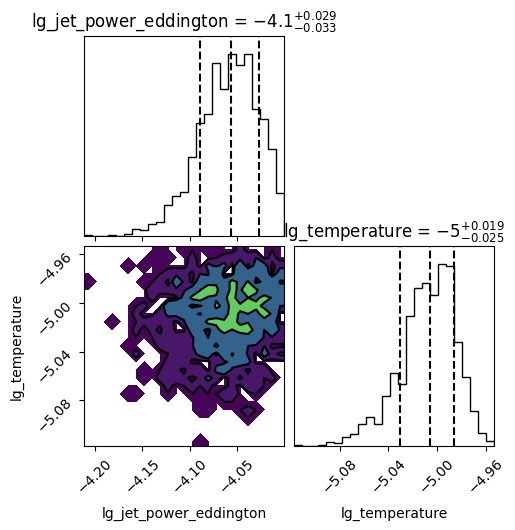

In [38]:
ar.corner_plot()